# From micrographs to a materials data system

## A live tour of the `microhard` data landscape

**Prepared for a discussion with Simon · 24 July 2026**

The project began as a small UHCS hardness proof of concept. The local
corpus now spans three alloy families and contains microscopy, process
records, composition, EBSD, measured microstructural descriptors,
replicated mechanical tests, hardness, CALPHAD outputs, and explicit
provenance.

> **The data bottleneck has changed.** We have substantial raw material.
> The next challenge is defensible entity resolution: deciding which
> images, process states, specimens, and property measurements may be
> joined without manufacturing false labels.

This notebook reads the downloaded archives directly from their verified
ZIP files. It does not extract or duplicate the multi-gigabyte source
data.

In [1]:
from __future__ import annotations

import csv
import io
import sqlite3
from collections import Counter
from pathlib import Path
from zipfile import ZipFile

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import Markdown, display
from PIL import Image

ROOT = Path.cwd()
if not (ROOT / "data").exists() and (ROOT.parent / "data").exists():
    ROOT = ROOT.parent
DATA = ROOT / "data"

NAVY = "#17324D"
BLUE = "#3A6EA5"
TEAL = "#2A9D8F"
GOLD = "#E9C46A"
ORANGE = "#F4A261"
RED = "#E76F51"
SLATE = "#607080"
PALE = "#EEF4F7"
MATERIAL_COLOURS = {"A": NAVY, "B": TEAL, "C": ORANGE, "D": RED}

plt.rcParams.update(
    {
        "figure.dpi": 130,
        "savefig.dpi": 160,
        "font.size": 10.5,
        "axes.titlesize": 12,
        "axes.titleweight": "bold",
        "axes.labelsize": 10,
        "axes.edgecolor": "#9AA7B2",
        "axes.spines.top": False,
        "axes.spines.right": False,
        "axes.grid": True,
        "grid.alpha": 0.18,
        "grid.linewidth": 0.8,
        "legend.frameon": False,
    }
)

def archive_files(path: Path):
    with ZipFile(path) as archive:
        return [
            item
            for item in archive.infolist()
            if not item.is_dir() and not item.filename.startswith("__MACOSX/")
        ]

def image_from_zip(path: Path, member: str) -> Image.Image:
    with ZipFile(path) as archive:
        image = Image.open(io.BytesIO(archive.read(member)))
        image.load()
    return image

def display_array(image: Image.Image) -> np.ndarray:
    if image.mode in {"RGB", "RGBA"}:
        return np.asarray(image.convert("RGB"))
    array = np.asarray(image.convert("I"))
    finite = array[np.isfinite(array)]
    low, high = np.percentile(finite, [1, 99])
    if high <= low:
        low, high = float(finite.min()), float(finite.max() or 1)
    return np.clip((array - low) / (high - low), 0, 1)

def read_zip_text(path: Path, member_suffix: str) -> str:
    with ZipFile(path) as archive:
        matches = [
            name
            for name in archive.namelist()
            if name.endswith(member_suffix) and not name.startswith("__MACOSX/")
        ]
        if len(matches) != 1:
            raise ValueError(f"Expected one {member_suffix!r} in {path}, got {matches}")
        return archive.read(matches[0]).decode("utf-8-sig", errors="replace")

def clean_axis(axis):
    axis.grid(axis="y", alpha=0.18)
    axis.spines["left"].set_color("#A9B4BC")
    axis.spines["bottom"].set_color("#A9B4BC")

print(f"Repository: {ROOT}")

Repository: /Users/jameshansen/Microstructural prediction/microhard


## 1 · What is actually on disk?

Counts below distinguish **files and fields of view** from independent
material states. They are an inventory, not a claim about statistical
sample size.

source,material,microscopy assets,property evidence,status
UHCSDB,2C–4Cr ultrahigh-carbon steel,961 SEM,7 directly measured hardness groups,integrated
Cited steel panels,Low-alloy and 35CrMo steels,19 SEM panels,10 condition/location HV groups,integrated
Zenodo 14163786,LPBF IN718; Gaussian/ring beam,22 BSE-SEM,10 HV states; 18 tensile rows,integrated HV
Zenodo 16603134,IN718 + NbC/TiC/B₄C,401 microscopy TIFF; 32 EBSD TIFF,12 tensile curves; HV1; carbide measurements,downloaded + verified
Zenodo 18800251,LPBF 316L; three powders,5 SEM; 3 EBSD map sets,HV1 replicates; grain-size distributions,downloaded + verified


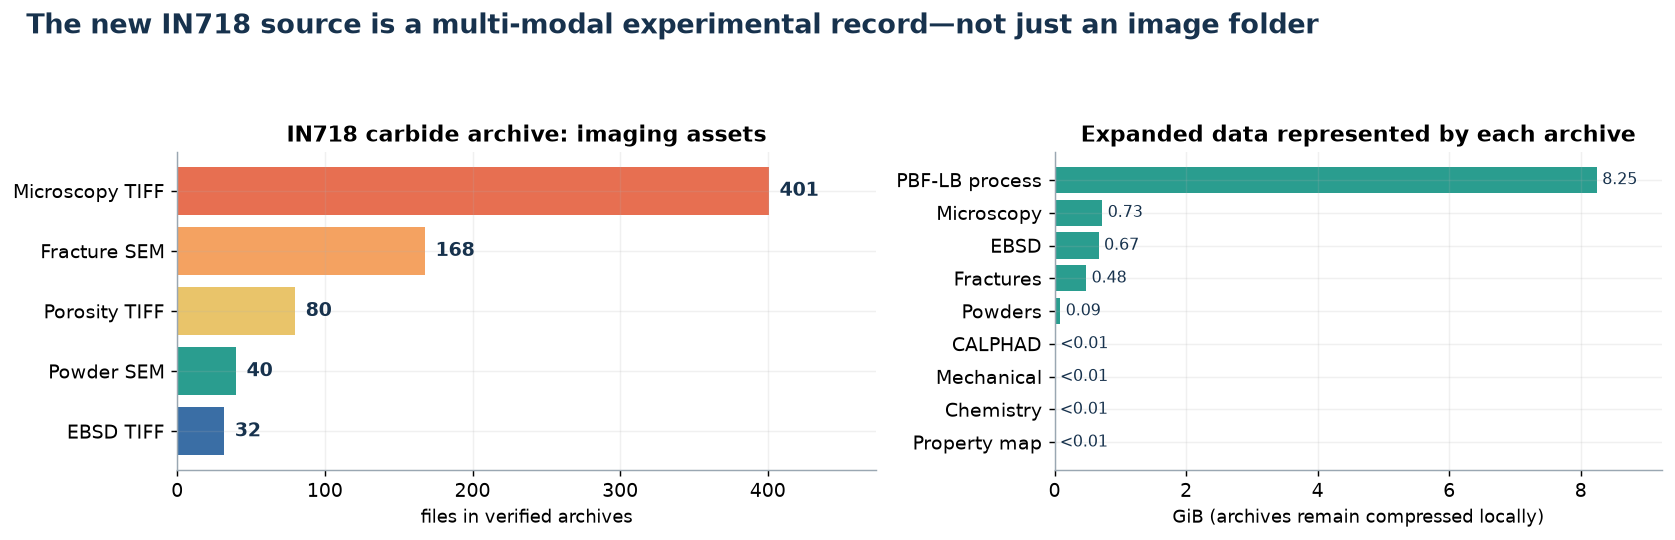

Verified local source archives represent 11.5 GiB when expanded.


In [2]:
carbide_root = DATA / "public_in718_carbides_2025" / "raw"
steel316_root = DATA / "public_316l_composition_2026" / "raw"

carbide_archives = {
    "Powders": carbide_root / "00_Powders.zip",
    "Chemistry": carbide_root / "01_Chemical_composition.zip",
    "PBF-LB process": carbide_root / "02_PBF-LB_process.zip",
    "CALPHAD": carbide_root / "03_CALPHAD.zip",
    "Microscopy": carbide_root / "04_Microscopy.zip",
    "Mechanical": carbide_root / "05_Mechanical_properties.zip",
    "EBSD": carbide_root / "06_EBSD.zip",
    "Fractures": carbide_root / "07_Fractures.zip",
    "Property map": carbide_root / "08_Tensile property map.zip",
}
steel316_archive = steel316_root / "Data-Impact_of_chemical_composition.zip"

archive_rows = []
for module, path in carbide_archives.items():
    files = archive_files(path)
    extensions = Counter(Path(item.filename).suffix.lower() for item in files)
    archive_rows.append(
        {
            "module": module,
            "files": len(files),
            "expanded GiB": sum(item.file_size for item in files) / 2**30,
            "TIFF": extensions[".tif"],
            "CSV": extensions[".csv"],
            "Excel": extensions[".xlsx"] + extensions[".xls"],
        }
    )
archive_inventory = pd.DataFrame(archive_rows)

uhcs_images = len(
    [path for path in (DATA / "micrographs").iterdir() if path.suffix.lower() in {".tif", ".png"}]
)
literature_manifest = pd.read_csv(DATA / "literature_steel" / "manifest.csv")
godec_audit = pd.read_csv(DATA / "public_in718_godec_2024" / "link_audit.csv")
godec_hardness = pd.read_csv(DATA / "public_in718_godec_2024" / "hardness.csv")
godec_tensile = pd.read_csv(DATA / "public_in718_godec_2024" / "tensile.csv")

microscopy_files = archive_files(carbide_archives["Microscopy"])
ebsd_files = archive_files(carbide_archives["EBSD"])
process_files = archive_files(carbide_archives["PBF-LB process"])
fracture_files = archive_files(carbide_archives["Fractures"])
powder_files = archive_files(carbide_archives["Powders"])
steel316_files = archive_files(steel316_archive)

landscape = pd.DataFrame(
    [
        {
            "source": "UHCSDB",
            "material": "2C–4Cr ultrahigh-carbon steel",
            "microscopy assets": f"{uhcs_images:,} SEM",
            "property evidence": "7 directly measured hardness groups",
            "status": "integrated",
        },
        {
            "source": "Cited steel panels",
            "material": "Low-alloy and 35CrMo steels",
            "microscopy assets": f"{len(literature_manifest):,} SEM panels",
            "property evidence": (
                f"{literature_manifest['specimen_id'].nunique()} condition/location HV groups"
            ),
            "status": "integrated",
        },
        {
            "source": "Zenodo 14163786",
            "material": "LPBF IN718; Gaussian/ring beam",
            "microscopy assets": f"{godec_audit['record_id'].nunique()} BSE-SEM",
            "property evidence": (
                f"{len(godec_hardness)} HV states; {len(godec_tensile)} tensile rows"
            ),
            "status": "integrated HV",
        },
        {
            "source": "Zenodo 16603134",
            "material": "IN718 + NbC/TiC/B₄C",
            "microscopy assets": (
                f"{sum(Path(i.filename).suffix.lower() == '.tif' for i in microscopy_files)} "
                "microscopy TIFF; "
                f"{sum(Path(i.filename).suffix.lower() == '.tif' for i in ebsd_files)} EBSD TIFF"
            ),
            "property evidence": "12 tensile curves; HV1; carbide measurements",
            "status": "downloaded + verified",
        },
        {
            "source": "Zenodo 18800251",
            "material": "LPBF 316L; three powders",
            "microscopy assets": (
                f"{sum(Path(i.filename).suffix.lower() == '.tif' for i in steel316_files)} SEM; "
                "3 EBSD map sets"
            ),
            "property evidence": "HV1 replicates; grain-size distributions",
            "status": "downloaded + verified",
        },
    ]
)

display(
    landscape.style
    .hide(axis="index")
    .set_properties(**{"text-align": "left", "border-color": "#DDE5EA"})
    .set_table_styles(
        [
            {
                "selector": "th",
                "props": [
                    ("background-color", NAVY),
                    ("color", "white"),
                    ("text-align", "left"),
                ],
            }
        ]
    )
)

fig, axes = plt.subplots(1, 2, figsize=(13, 4.2), gridspec_kw={"width_ratios": [1.15, 1]})

asset_counts = pd.Series(
    {
        "Microscopy TIFF": sum(
            Path(item.filename).suffix.lower() == ".tif" for item in microscopy_files
        ),
        "Fracture SEM": sum(
            Path(item.filename).suffix.lower() == ".tif" for item in fracture_files
        ),
        "Porosity TIFF": sum(
            Path(item.filename).suffix.lower() == ".tif" for item in process_files
        ),
        "Powder SEM": sum(
            Path(item.filename).suffix.lower() == ".tif" for item in powder_files
        ),
        "EBSD TIFF": sum(
            Path(item.filename).suffix.lower() == ".tif" for item in ebsd_files
        ),
    }
).sort_values()
axes[0].barh(asset_counts.index, asset_counts.values, color=[BLUE, TEAL, GOLD, ORANGE, RED])
for y, value in enumerate(asset_counts.values):
    axes[0].text(value + 7, y, f"{value:,}", va="center", color=NAVY, fontweight="bold")
axes[0].set_title("IN718 carbide archive: imaging assets")
axes[0].set_xlabel("files in verified archives")
axes[0].set_xlim(0, asset_counts.max() * 1.18)
axes[0].grid(axis="x", alpha=0.18)

module_plot = archive_inventory.sort_values("expanded GiB")
axes[1].barh(module_plot["module"], module_plot["expanded GiB"], color=TEAL)
for y, value in enumerate(module_plot["expanded GiB"]):
    label = f"{value:.2f}" if value >= 0.01 else "<0.01"
    axes[1].text(value + 0.08, y, label, va="center", color=NAVY, fontsize=9)
axes[1].set_title("Expanded data represented by each archive")
axes[1].set_xlabel("GiB (archives remain compressed locally)")
axes[1].set_xlim(0, module_plot["expanded GiB"].max() * 1.12)
axes[1].grid(axis="x", alpha=0.18)

fig.suptitle(
    "The new IN718 source is a multi-modal experimental record—not just an image folder",
    x=0.02,
    ha="left",
    color=NAVY,
    fontsize=15,
    fontweight="bold",
)
fig.tight_layout(rect=[0, 0, 1, 0.9])
plt.show()

print(
    f"Verified local source archives represent "
    f"{archive_inventory['expanded GiB'].sum() + sum(i.file_size for i in steel316_files)/2**30:.1f} "
    "GiB when expanded."
)

### What those counts contain

The carbide-additive IN718 record includes four material variants:

- **A** — reference IN718;
- **B** — IN718 + 0.6 wt.% NbC;
- **C** — IN718 + 0.6 wt.% TiC;
- **D** — IN718 + 0.2 wt.% micron-scale B₄C.

Its microscopy archive includes optical fields, SEM in as-built and
heat-treated states, carbide-focused SEM, binary masks, particle tables,
and EDS line scans. The process archive includes 80 large porosity TIFFs
and build parameter workbooks. Fracture images are retained as
**post-test outcomes** and must not be used to predict the tensile result
that created them.

## 2 · A visual tour across the corpus

These are raw or provenance-preserving source images. Different scales,
detectors, preparation routes, annotations, and bit depths are visible
immediately—which is why acquisition metadata must be modelled rather
than silently pooled.

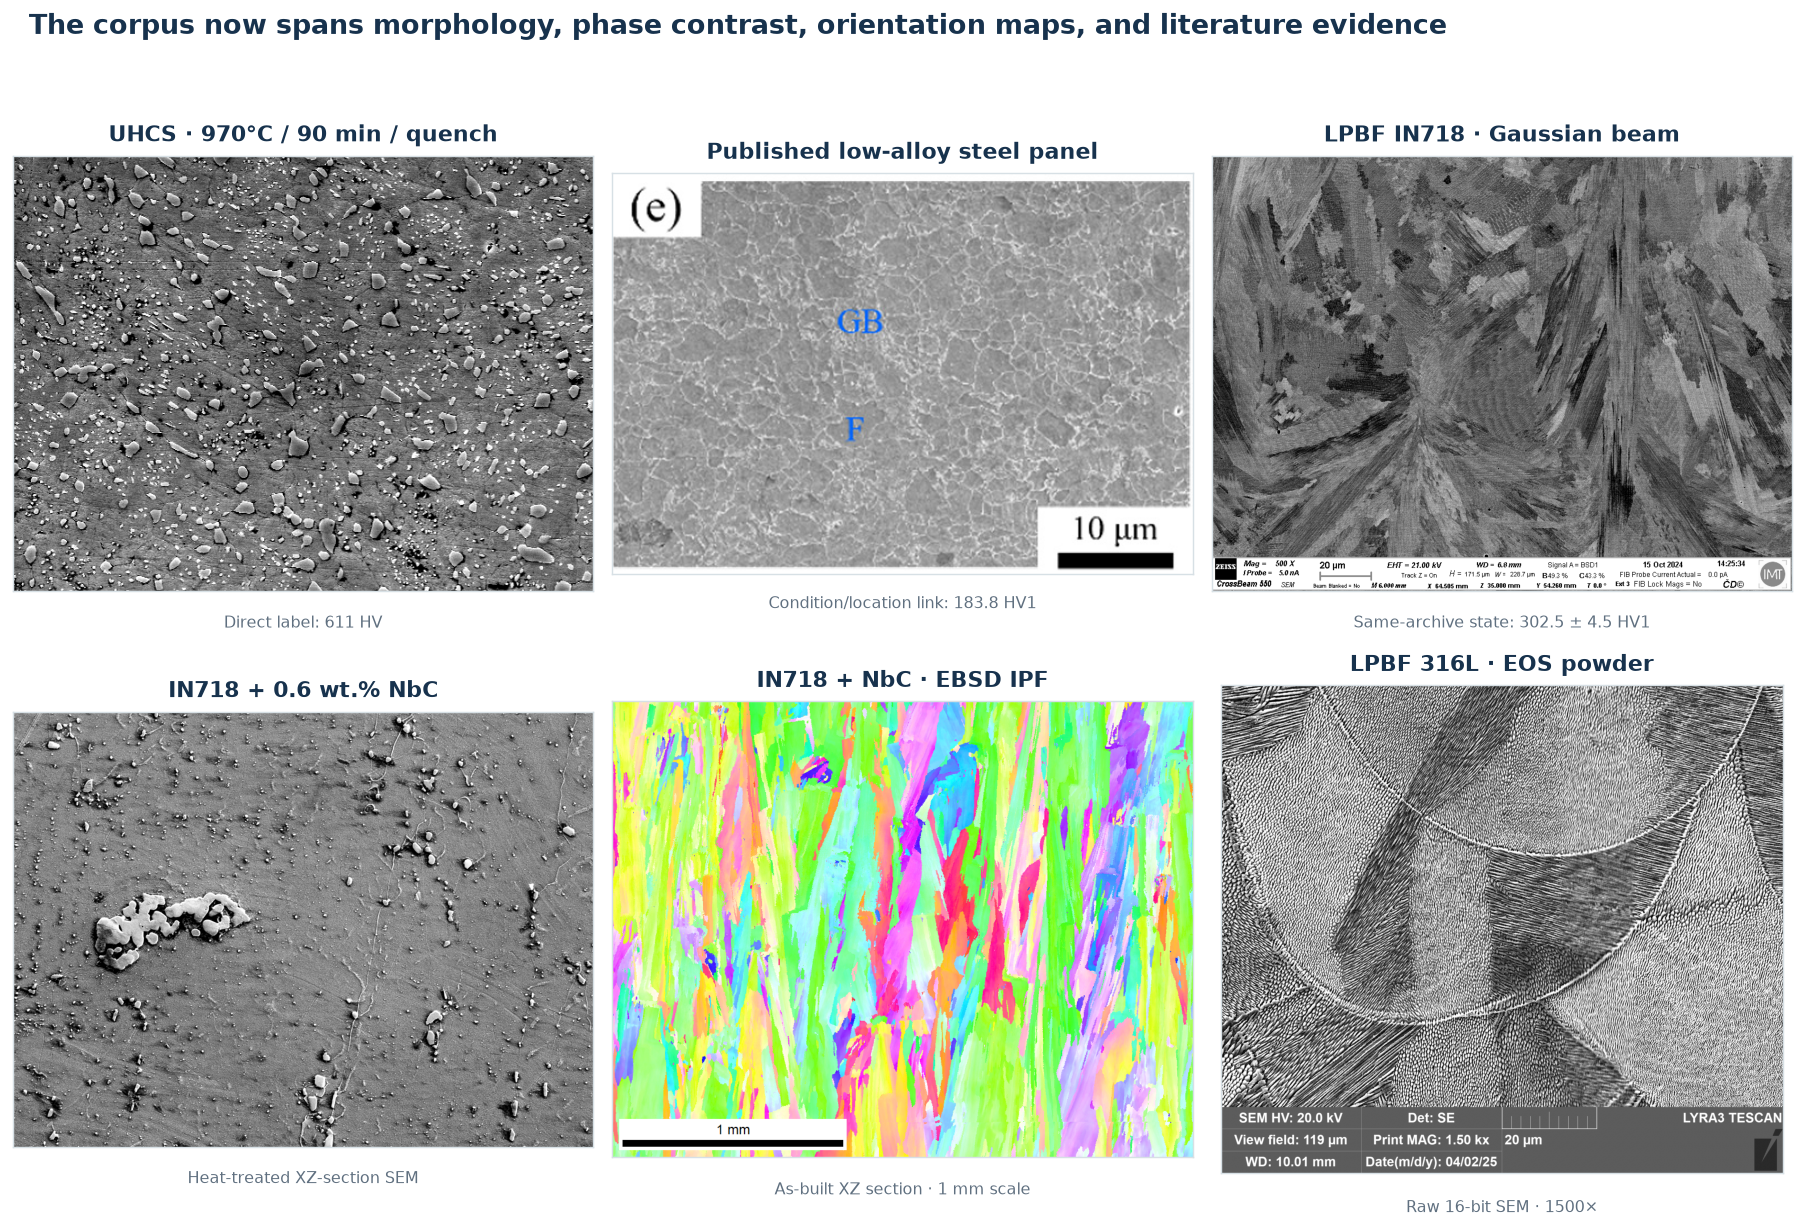

In [3]:
carbide_microscopy = carbide_archives["Microscopy"]
carbide_ebsd = carbide_archives["EBSD"]

gallery = [
    (
        Image.open(DATA / "micrographs" / "micrograph1022.png"),
        "UHCS · 970°C / 90 min / quench",
        "Direct label: 611 HV",
    ),
    (
        Image.open(
            DATA
            / "literature_steel"
            / "guan_2026_metals_16_243"
            / "figure3_e.jpg"
        ),
        "Published low-alloy steel panel",
        "Condition/location link: 183.8 HV1",
    ),
    (
        Image.open(DATA / "public_in718_godec_2024" / "raw" / "BEI AB Gauss 1.tif"),
        "LPBF IN718 · Gaussian beam",
        "Same-archive state: 302.5 ± 4.5 HV1",
    ),
    (
        image_from_zip(
            carbide_microscopy,
            "04_Microscopy/SEM AB and HT-treated/PlainImages/B-HT-XZ-100.tif",
        ),
        "IN718 + 0.6 wt.% NbC",
        "Heat-treated XZ-section SEM",
    ),
    (
        image_from_zip(
            carbide_ebsd,
            "06_EBSD/AB/B_XZ_AB_x100_IPF_map.tif",
        ),
        "IN718 + NbC · EBSD IPF",
        "As-built XZ section · 1 mm scale",
    ),
    (
        image_from_zip(
            steel316_archive,
            "Data-Impact_of_chemical_composition/SEM/"
            "316L_EOS_80Cel_67rot_DEF_23_1500x.tif",
        ),
        "LPBF 316L · EOS powder",
        "Raw 16-bit SEM · 1500×",
    ),
]

fig, axes = plt.subplots(2, 3, figsize=(14, 9.3))
for axis, (image, title, subtitle) in zip(axes.flat, gallery, strict=True):
    array = display_array(image)
    axis.imshow(array, cmap="gray" if array.ndim == 2 else None)
    axis.set_title(title, color=NAVY, pad=8)
    axis.text(
        0.5,
        -0.055,
        subtitle,
        transform=axis.transAxes,
        ha="center",
        va="top",
        color=SLATE,
        fontsize=9,
    )
    axis.set_xticks([])
    axis.set_yticks([])
    for spine in axis.spines.values():
        spine.set_visible(True)
        spine.set_color("#D7E0E5")
fig.suptitle(
    "The corpus now spans morphology, phase contrast, orientation maps, and literature evidence",
    x=0.02,
    ha="left",
    color=NAVY,
    fontsize=15,
    fontweight="bold",
)
fig.tight_layout(rect=[0, 0, 1, 0.94], h_pad=4.8, w_pad=1.0)
plt.show()

## 3 · What is already linked and auditable?

The Godec IN718 archive is the first complete runtime demonstration.
Image filenames encode build strategy, state, and heat-treatment
temperature. That supports high-confidence links to ten hardness states.

Tensile measurements are richer but orientation-sensitive. The images do
not identify H/V orientation, so the notebook shows the data while the
runtime correctly refuses to auto-attach it.

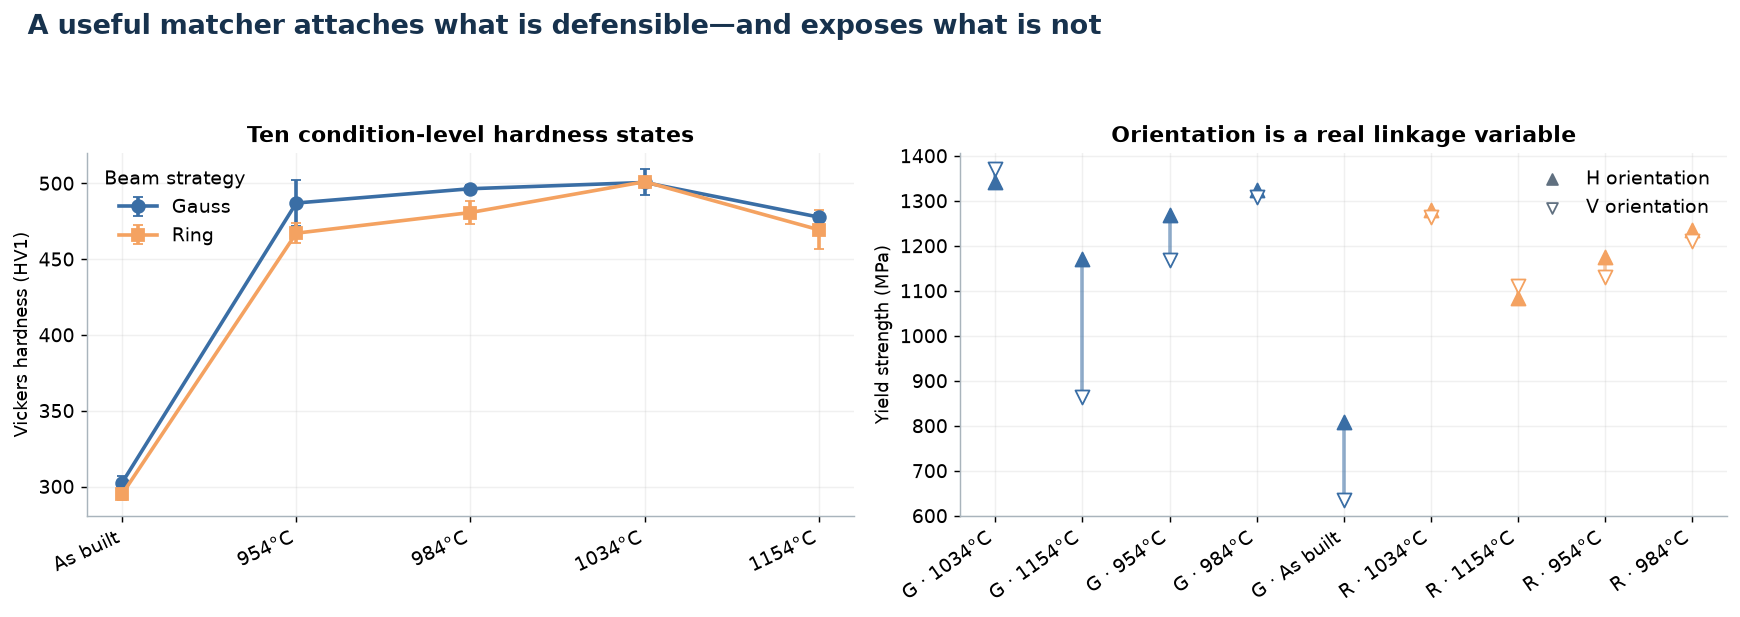

22 images have auto-attached hardness; 174 orientation-sensitive candidates remain review-only.


In [4]:
hardness = godec_hardness.copy()
hardness["condition"] = hardness["temperature_c"].apply(
    lambda value: "As built" if pd.isna(value) else f"{int(value)}°C"
)
condition_order = ["As built", "954°C", "984°C", "1034°C", "1154°C"]

tensile = godec_tensile.dropna(subset=["yield_strength_mpa"]).copy()
tensile["condition"] = tensile["temperature_c"].apply(
    lambda value: "As built" if pd.isna(value) else f"{int(value)}°C"
)
yield_pairs = tensile.pivot_table(
    index=["build_strategy", "condition"],
    columns="orientation",
    values="yield_strength_mpa",
).dropna(subset=["H", "V"])
yield_pairs = yield_pairs.reset_index()

fig, axes = plt.subplots(1, 2, figsize=(13.5, 4.8))

for strategy, colour, marker in [("Gauss", BLUE, "o"), ("Ring", ORANGE, "s")]:
    subset = hardness[hardness["build_strategy"] == strategy].set_index("condition")
    subset = subset.reindex(condition_order).dropna(subset=["hardness_hv"])
    positions = [condition_order.index(item) for item in subset.index]
    axes[0].errorbar(
        positions,
        subset["hardness_hv"],
        yerr=subset["hardness_sd_hv"],
        marker=marker,
        markersize=7,
        linewidth=2,
        capsize=3,
        color=colour,
        label=strategy,
    )
axes[0].set_xticks(range(len(condition_order)), condition_order, rotation=25, ha="right")
axes[0].set_ylabel("Vickers hardness (HV1)")
axes[0].set_title("Ten condition-level hardness states")
axes[0].legend(title="Beam strategy")
clean_axis(axes[0])

labels = []
for index, row in yield_pairs.iterrows():
    colour = BLUE if row["build_strategy"] == "Gauss" else ORANGE
    axes[1].plot([index, index], [row["V"], row["H"]], color=colour, alpha=0.55, linewidth=2)
    axes[1].scatter(index, row["H"], marker="^", s=60, color=colour, zorder=3)
    axes[1].scatter(index, row["V"], marker="v", s=60, facecolor="white", edgecolor=colour, zorder=3)
    labels.append(f"{row['build_strategy'][0]} · {row['condition']}")
axes[1].set_xticks(range(len(labels)), labels, rotation=35, ha="right")
axes[1].set_ylabel("Yield strength (MPa)")
axes[1].set_title("Orientation is a real linkage variable")
axes[1].scatter([], [], marker="^", color=SLATE, label="H orientation")
axes[1].scatter([], [], marker="v", facecolor="white", edgecolor=SLATE, label="V orientation")
axes[1].legend()
clean_axis(axes[1])

fig.suptitle(
    "A useful matcher attaches what is defensible—and exposes what is not",
    x=0.02,
    ha="left",
    color=NAVY,
    fontsize=15,
    fontweight="bold",
)
fig.tight_layout(rect=[0, 0, 1, 0.91])
plt.show()

auto_attached = godec_audit[godec_audit["auto_attach"]]
print(
    f"{auto_attached['record_id'].nunique()} images have auto-attached hardness; "
    f"{godec_audit.loc[~godec_audit['auto_attach'], 'property_name'].count()} "
    "orientation-sensitive candidates remain review-only."
)

## 4 · The new IN718 archive contains paired structure and response

The most immediately useful addition is not the image count. It is the
combination of:

- four controlled material variants;
- repeated SEM and EBSD observations;
- existing carbide masks and particle tables;
- three independent tensile curves per variant;
- hardness and a literature property map.

That supports a family-specific process–structure–property pilot once
specimen and state keys have been audited.

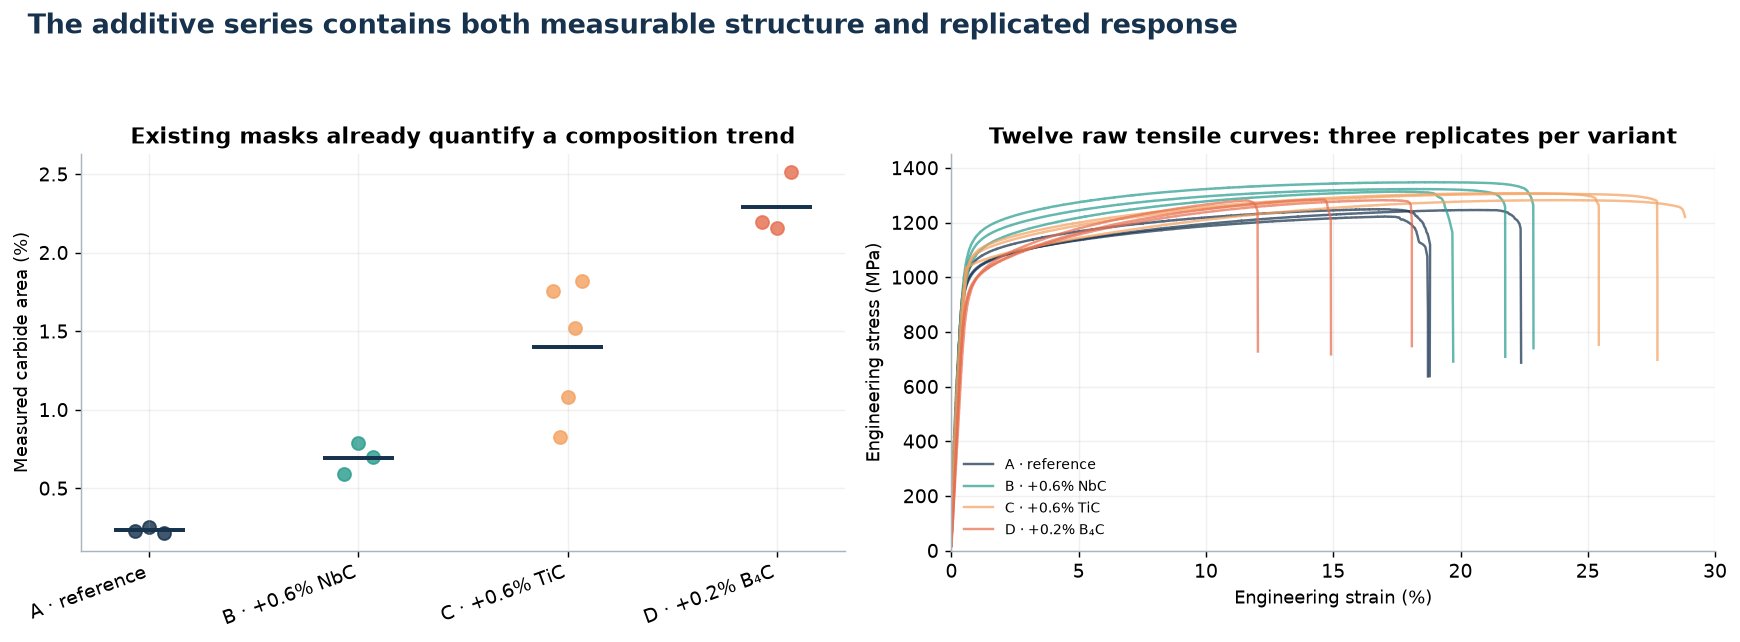

,replicates,UTS_mean_MPa,UTS_sd_MPa,terminal_strain_mean_pct
A · reference,3,1239.2,14.8,20.0
B · +0.6% NbC,3,1328.1,17.7,21.4
C · +0.6% TiC,3,1298.6,14.2,27.3
D · +0.2% B₄C,3,1282.7,2.0,15.0


Plotting note: a discontinuous terminal point in TiC replicate 3 is shown as a line break; the source record itself is unchanged.


In [5]:
summary_rows = []
with ZipFile(carbide_microscopy) as archive:
    for member in archive.namelist():
        if not member.lower().endswith("_summary.csv"):
            continue
        row = pd.read_csv(io.BytesIO(archive.read(member))).iloc[0]
        summary_rows.append(
            {
                "material": Path(member).name[0],
                "field": row["Slice"],
                "particle_count": float(row["Count"]),
                "area_pct": float(row["%Area"]),
                "mean_particle_area_um2": float(row["Average Size"]),
            }
        )
carbide_summary = pd.DataFrame(summary_rows)

mechanical_archive = carbide_archives["Mechanical"]
tensile_curves = []
with ZipFile(mechanical_archive) as archive:
    members = [
        name
        for name in archive.namelist()
        if name.lower().endswith(".csv") and "Specimen_RawData" in name
    ]
    for member in members:
        frame = pd.read_csv(
            io.BytesIO(archive.read(member)),
            sep=";",
            header=0,
            names=["time_s", "extension_mm", "force_n", "blank", "stress_mpa", "strain"],
        )
        material = Path(member).parts[-2].split("_")[0]
        replicate = int(Path(member).stem.rsplit("_", 1)[-1])
        frame = frame[frame["strain"].between(0, 0.35)].copy()
        frame["material"] = material
        frame["replicate"] = replicate
        tensile_curves.append(frame)
tensile_curves = pd.concat(tensile_curves, ignore_index=True)

material_names = {
    "A": "A · reference",
    "B": "B · +0.6% NbC",
    "C": "C · +0.6% TiC",
    "D": "D · +0.2% B₄C",
}

fig, axes = plt.subplots(1, 2, figsize=(13.5, 5.0))

for material, group in carbide_summary.groupby("material"):
    x = np.full(len(group), list("ABCD").index(material), dtype=float)
    x += np.linspace(-0.07, 0.07, len(group))
    axes[0].scatter(
        x,
        group["area_pct"],
        s=52,
        color=MATERIAL_COLOURS[material],
        alpha=0.82,
        label=material_names[material],
    )
    axes[0].plot(
        [list("ABCD").index(material) - 0.16, list("ABCD").index(material) + 0.16],
        [group["area_pct"].mean()] * 2,
        color=NAVY,
        linewidth=2.2,
    )
axes[0].set_xticks(range(4), [material_names[key] for key in "ABCD"], rotation=20, ha="right")
axes[0].set_ylabel("Measured carbide area (%)")
axes[0].set_title("Existing masks already quantify a composition trend")
clean_axis(axes[0])

for (material, replicate), curve in tensile_curves.groupby(["material", "replicate"]):
    plot_curve = curve.copy()
    # One supplied TiC trace has a discontinuous terminal sensor point.
    # Break the drawn line there rather than connecting it across the chart.
    discontinuity = plot_curve["strain"].diff().abs().gt(0.02)
    plot_curve.loc[discontinuity, ["strain", "stress_mpa"]] = np.nan
    axes[1].plot(
        plot_curve["strain"] * 100,
        plot_curve["stress_mpa"],
        color=MATERIAL_COLOURS[material],
        alpha=0.72,
        linewidth=1.35,
        label=material_names[material] if replicate == 1 else None,
    )
axes[1].set_xlim(0, 30)
axes[1].set_ylim(0, 1450)
axes[1].set_xlabel("Engineering strain (%)")
axes[1].set_ylabel("Engineering stress (MPa)")
axes[1].set_title("Twelve raw tensile curves: three replicates per variant")
axes[1].legend(fontsize=8)
clean_axis(axes[1])

fig.suptitle(
    "The additive series contains both measurable structure and replicated response",
    x=0.02,
    ha="left",
    color=NAVY,
    fontsize=15,
    fontweight="bold",
)
fig.tight_layout(rect=[0, 0, 1, 0.91])
plt.show()

tensile_summary = (
    tensile_curves.groupby(["material", "replicate"])
    .agg(UTS_MPa=("stress_mpa", "max"), terminal_strain_pct=("strain", lambda x: 100 * x.max()))
    .reset_index()
    .groupby("material")
    .agg(
        replicates=("replicate", "nunique"),
        UTS_mean_MPa=("UTS_MPa", "mean"),
        UTS_sd_MPa=("UTS_MPa", "std"),
        terminal_strain_mean_pct=("terminal_strain_pct", "mean"),
    )
    .round(1)
)
tensile_summary.index = [material_names[index] for index in tensile_summary.index]
display(tensile_summary)
print(
    "Plotting note: a discontinuous terminal point in TiC replicate 3 is shown as "
    "a line break; the source record itself is unchanged."
)

### The structure signal is not cosmetic

The supplied masks report increasing carbide area from the reference
material through NbC, TiC, and B₄C variants. The three tensile repeats
also show that the variants are not interchangeable. This is the kind
of controlled series in which composition, processing, microstructure,
and response can be modelled together—provided the linkage audit confirms
the state and specimen relationships.

## 5 · A compact 316L experiment adds a second family

The 316L archive is smaller but unusually coherent: three powder sources,
five raw SEM fields, three EBSD map sets, full EBSD backing data, HV1
replicates, and area-weighted grain-size distributions.

It is useful both as a second-family test and as a warning against
one-variable explanations.

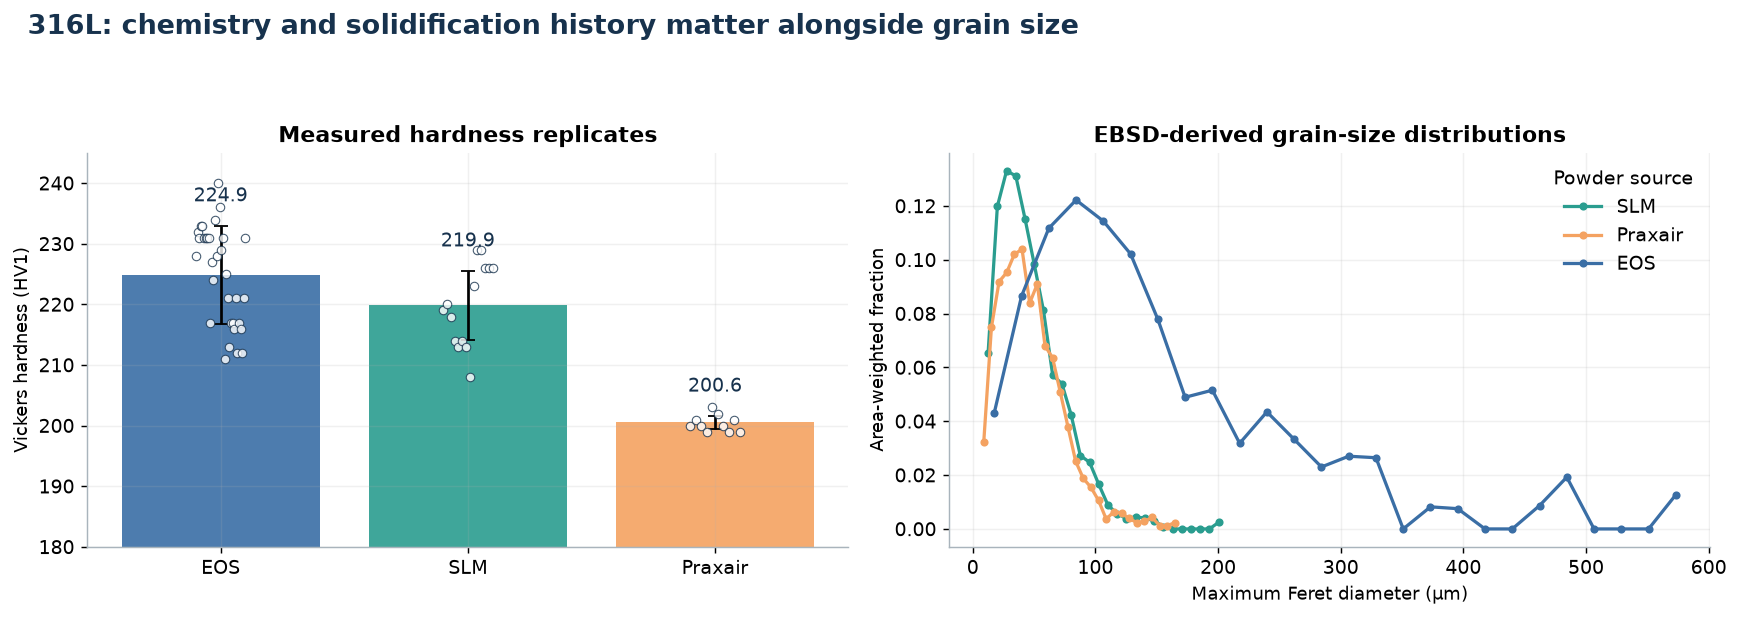

,reported mean HV1,reported HV1 SD,area-weighted mean Feret diameter (µm)
EOS,224.9,8.1,153.3
SLM,219.9,5.7,47.9
Praxair,200.6,1.1,47.9


EOS has a much larger area-weighted Feret diameter than SLM or Praxair, yet it is not the softest material. Grain size alone cannot explain this series.


In [6]:
hardness_text = read_zip_text(steel316_archive, "Hardness Praxair, EOS, SLM.csv")
hardness_rows = list(csv.reader(io.StringIO(hardness_text), delimiter=";"))
replicate_columns = {"EOS": 11, "SLM": 12, "Praxair": 13}
hardness_replicates = {}
for material, column in replicate_columns.items():
    values = []
    for row in hardness_rows[17:]:
        if column < len(row) and row[column].strip().isdigit():
            values.append(float(row[column]))
    hardness_replicates[material] = np.asarray(values)

def decimal_comma(value: str) -> float:
    return float(value.replace(",", "."))

reported_hardness = {
    "EOS": {
        "mean": decimal_comma(hardness_rows[23][3]),
        "sd": decimal_comma(hardness_rows[24][3]),
    },
    "SLM": {
        "mean": decimal_comma(hardness_rows[12][10]),
        "sd": decimal_comma(hardness_rows[13][10]),
    },
    "Praxair": {
        "mean": decimal_comma(hardness_rows[15][5]),
        "sd": decimal_comma(hardness_rows[16][5]),
    },
}

feret_text = read_zip_text(steel316_archive, "Max Feret diameter.csv")
feret_rows = list(csv.reader(io.StringIO(feret_text), delimiter=";"))

feret = {}
for material, start in {"SLM": 0, "Praxair": 6, "EOS": 12}.items():
    points = []
    for row in feret_rows[2:28]:
        low = decimal_comma(row[start])
        high = decimal_comma(row[start + 1])
        weight = decimal_comma(row[start + 2])
        points.append(((low + high) / 2, weight))
    feret[material] = pd.DataFrame(points, columns=["diameter_um", "area_fraction"])

powder_colours = {"EOS": BLUE, "SLM": TEAL, "Praxair": ORANGE}
fig, axes = plt.subplots(1, 2, figsize=(13.5, 4.8))

positions = np.arange(3)
order = ["EOS", "SLM", "Praxair"]
means = [reported_hardness[name]["mean"] for name in order]
stds = [reported_hardness[name]["sd"] for name in order]
axes[0].bar(
    positions,
    means,
    yerr=stds,
    capsize=4,
    color=[powder_colours[name] for name in order],
    alpha=0.9,
)
for index, name in enumerate(order):
    values = hardness_replicates[name]
    jitter = np.linspace(-0.10, 0.10, len(values))
    axes[0].scatter(
        index + jitter,
        values,
        s=22,
        facecolor="white",
        edgecolor=NAVY,
        linewidth=0.6,
        alpha=0.8,
        zorder=3,
    )
    axes[0].text(index, means[index] + stds[index] + 4, f"{means[index]:.1f}", ha="center", color=NAVY)
axes[0].set_xticks(positions, order)
axes[0].set_ylabel("Vickers hardness (HV1)")
axes[0].set_ylim(180, 245)
axes[0].set_title("Measured hardness replicates")
clean_axis(axes[0])

weighted_means = {}
for material, frame in feret.items():
    axes[1].plot(
        frame["diameter_um"],
        frame["area_fraction"],
        marker="o",
        markersize=3.5,
        linewidth=1.8,
        color=powder_colours[material],
        label=material,
    )
    weighted_means[material] = np.average(
        frame["diameter_um"], weights=frame["area_fraction"]
    )
axes[1].set_xlabel("Maximum Feret diameter (µm)")
axes[1].set_ylabel("Area-weighted fraction")
axes[1].set_title("EBSD-derived grain-size distributions")
axes[1].legend(title="Powder source")
clean_axis(axes[1])

fig.suptitle(
    "316L: chemistry and solidification history matter alongside grain size",
    x=0.02,
    ha="left",
    color=NAVY,
    fontsize=15,
    fontweight="bold",
)
fig.tight_layout(rect=[0, 0, 1, 0.91])
plt.show()

comparison = pd.DataFrame(
    {
        "reported mean HV1": {name: reported_hardness[name]["mean"] for name in order},
        "reported HV1 SD": {name: reported_hardness[name]["sd"] for name in order},
        "area-weighted mean Feret diameter (µm)": weighted_means,
    }
).round(1)
display(comparison)

print(
    "EOS has a much larger area-weighted Feret diameter than SLM or Praxair, "
    "yet it is not the softest material. Grain size alone cannot explain this series."
)

## 6 · Readiness: volume is no longer the only constraint

The matrix below separates “data exists” from “the runtime can use it
defensibly.” **Partial** means that relevant metadata exists but the
exact specimen/state relationship still needs audit.

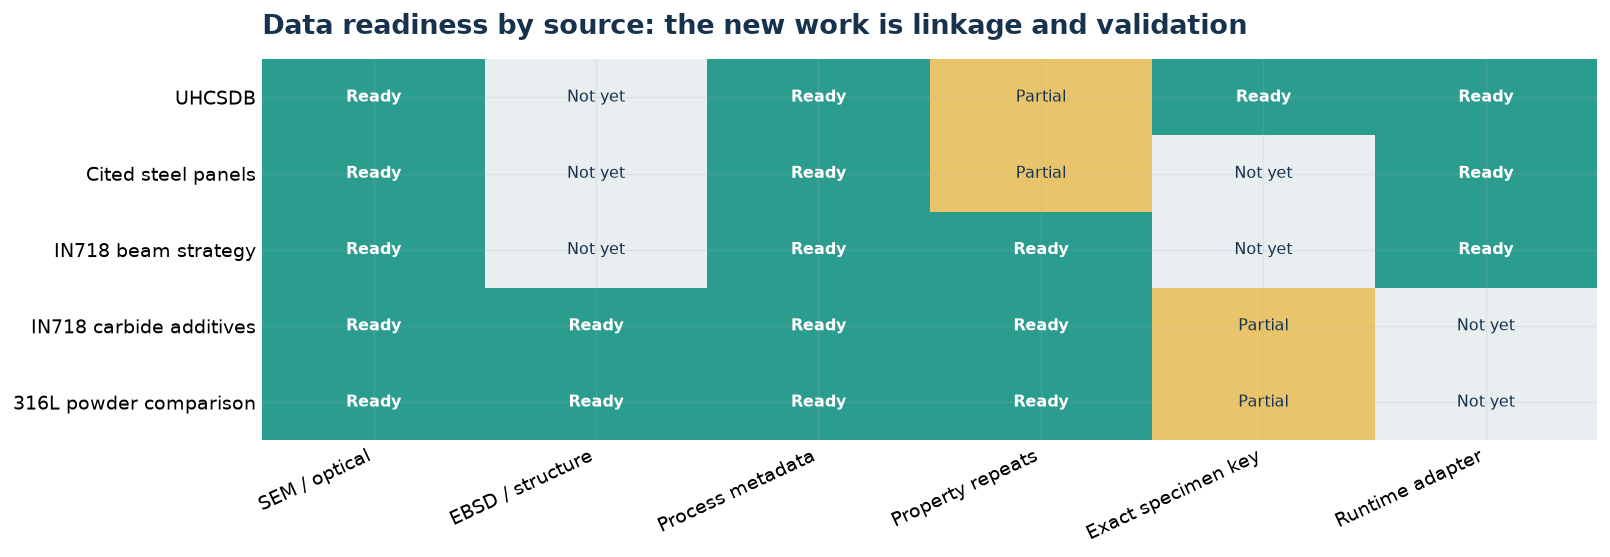

In [7]:
readiness_labels = ["Not yet", "Partial", "Ready"]
readiness = pd.DataFrame(
    {
        "SEM / optical": [2, 2, 2, 2, 2],
        "EBSD / structure": [0, 0, 0, 2, 2],
        "Process metadata": [2, 2, 2, 2, 2],
        "Property repeats": [1, 1, 2, 2, 2],
        "Exact specimen key": [2, 0, 0, 1, 1],
        "Runtime adapter": [2, 2, 2, 0, 0],
    },
    index=[
        "UHCSDB",
        "Cited steel panels",
        "IN718 beam strategy",
        "IN718 carbide additives",
        "316L powder comparison",
    ],
)

fig, axis = plt.subplots(figsize=(12.5, 4.4))
cmap = plt.matplotlib.colors.ListedColormap(["#E9EEF1", GOLD, TEAL])
axis.imshow(readiness.to_numpy(), cmap=cmap, vmin=0, vmax=2, aspect="auto")
axis.set_xticks(range(readiness.shape[1]), readiness.columns, rotation=25, ha="right")
axis.set_yticks(range(readiness.shape[0]), readiness.index)
for row in range(readiness.shape[0]):
    for column in range(readiness.shape[1]):
        value = int(readiness.iloc[row, column])
        axis.text(
            column,
            row,
            readiness_labels[value],
            ha="center",
            va="center",
            color="white" if value == 2 else NAVY,
            fontweight="bold" if value == 2 else "normal",
            fontsize=9,
        )
axis.set_title(
    "Data readiness by source: the new work is linkage and validation",
    loc="left",
    color=NAVY,
    fontsize=15,
    pad=14,
)
axis.tick_params(length=0)
for spine in axis.spines.values():
    spine.set_visible(False)
fig.tight_layout()
plt.show()

## What this now enables

### Immediate, defensible work

1. **Build the carbide-IN718 adapter.** Parse the A–D material code,
   state, section, process, and replicate identities while keeping
   fracture surfaces in a separate post-mortem task.
2. **Audit exact specimen linkage.** Determine whether the tensile,
   hardness, SEM, EBSD, and carbide measurements share physical
   specimens or only material/process batches.
3. **Run a family-specific representation benchmark.** Compare image
   features, carbide descriptors, EBSD grain statistics, and metadata
   under held-out material/state splits.
4. **Use 316L as an external-family test.** It can reveal whether a
   representation transfers or merely memorises IN718 acquisition and
   study effects.

### Claims the data does not yet support

- Hundreds of fields do not mean hundreds of independent specimens.
- Same-archive condition links are useful training evidence, not
  exact-specimen validation.
- Fracture surfaces cannot be used as pre-test inputs for the tensile
  property that produced them.
- A generative model is not inverse design until a forward
  process–structure–property model generalises with calibrated
  uncertainty.

---

## Questions for Simon

1. Which variables make two IN718 observations the *same material
   state* for hardness and tensile response?
2. Is batch-level SEM → bulk property linkage acceptable for training
   if exact specimens are reserved for validation?
3. Which representation is physically appropriate here: SEM texture,
   carbide morphology, EBSD grain structure, or a hybrid?
4. What held-out experiment would be convincing—specimens, material
   variants, heat-treatment states, or whole studies?
5. Does the carbide-additive series justify staying with IN718, or is
   there a stronger topology-governed target and dataset?

> **Proposed meeting outcome:** agree the minimum linkage key, select one
> alloy/property benchmark, and define the exact-specimen validation
> standard before modelling.

**Local provenance:**

[Zenodo 14163786](https://doi.org/10.5281/zenodo.14163786) ·
[Zenodo 16603134](https://doi.org/10.5281/zenodo.16603134) ·
[Zenodo 18800251](https://doi.org/10.5281/zenodo.18800251)